# 08 — From extractions to an ML dataset

AerEO's promise: every job writes GeoTIFFs aligned to the **same Major TOM grid** plus an `artifacts.parquet` catalog, so outputs from different dates — and different **sensors** — merge directly into ML-ready tensors. No manual reprojection, no alignment code.

This notebook proves it end to end:

1. Run **three jobs** over the same AOI and grid: Sentinel-2 NDVI at two dates, plus a **Sentinel-1 SAR** scene.
2. Join their catalogs by `grid_cell`.
3. **Fill the gaps**: mosaic multiple scenes per cell so partial footprints become full coverage.
4. Stack the per-cell windows into a single multi-sensor tensor: `ndvi_t1`, `ndvi_t2`, `vv`, `vh` channels.
5. Save the merged **Major TOM index**: one GeoParquet row per (cell, scene), all constellations in one table — then load a single shared cell back from it.

In [1]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz,pc]"

In [2]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files (job_sentinel2-ndvi.yaml inherits from job_sentinel2.yaml)
for name in ["job_sentinel2.yaml", "job_sentinel2-ndvi.yaml", "job_sentinel1.yaml"]:
    urllib.request.urlretrieve(
        f"{GITHUB_RAW}/examples/config/{name}",
        f"config/{name}",
    )

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)

## Step 1 — Three jobs, one grid

We reuse `config/job_sentinel2-ndvi.yaml` (Sentinel-2 red+nir → NDVI) at two date ranges, and `config/job_sentinel1.yaml` (Sentinel-1 GRD `vv`/`vh` from Planetary Computer, the same setup as notebook 07). Only the **date range**, **job name**, and **output URI** change via Hydra overrides — the grid (`grid_dist: 10_000`) and AOI stay identical, which is what makes the outputs joinable.

Note the second Sentinel-2 window is **13 days wide**: more dates means more scenes per grid cell, and more scenes is exactly what we need to fill coverage gaps in Step 3.

In [3]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

def load_ndvi_job(name: str, start: str, end: str) -> ExtractionJob:
    return ExtractionJob.load_from_config(
        config_dir="config",
        config_name="job_sentinel2-ndvi",
        overrides=[
            f"name={name}",
            f"output_uri=/tmp/aereo_ml/{name}",
            f"search.start_datetime={start}",
            f"search.end_datetime={end}",
        ],
    )

job_t1 = load_ndvi_job("ndvi_t1", "2024-01-01T00:00:00Z", "2024-01-03T23:59:59Z")
job_t2 = load_ndvi_job("ndvi_t2", "2024-01-08T00:00:00Z", "2024-01-20T23:59:59Z")

job_s1 = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel1",
    overrides=["name=s1", "output_uri=/tmp/aereo_ml/s1"],
)

In [4]:
local_exec = LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache())

def run(job: ExtractionJob) -> str:
    assets = job.search()
    tasks = job.build_tasks(assets)
    artifacts = job.execute(tasks, executor=local_exec)
    catalog = job.write_catalog(artifacts)
    print(f"{job.name}: {len(artifacts)} artifacts -> {catalog}")
    return catalog

catalog_t1 = run(job_t1)

2026-07-27 12:39:44 [info     ] search_called                  provider=search_stac


2026-07-27 12:39:47 [info     ] build_tasks_start              assets=4 builder=build_grouped_tasks


2026-07-27 12:39:47 [info     ] execute_start                  executor=LocalExecutor task_count=2


ndvi_t1: 14 artifacts -> /tmp/aereo_ml/ndvi_t1/artifacts.parquet


In [5]:
catalog_t2 = run(job_t2)

2026-07-27 12:39:47 [info     ] search_called                  provider=search_stac


2026-07-27 12:39:48 [info     ] build_tasks_start              assets=16 builder=build_grouped_tasks


2026-07-27 12:39:48 [info     ] execute_start                  executor=LocalExecutor task_count=8


ndvi_t2: 56 artifacts -> /tmp/aereo_ml/ndvi_t2/artifacts.parquet


In [6]:
catalog_s1 = run(job_s1)

2026-07-27 12:39:49 [info     ] search_called                  provider=search_stac


2026-07-27 12:39:51 [info     ] build_tasks_start              assets=4 builder=build_grouped_tasks


2026-07-27 12:39:51 [info     ] execute_start                  executor=LocalExecutor task_count=2


/home/fran/repos/aereo/.venv/lib/python3.13/site-packages/pydantic/_internal/_validate_call.py:137: UserWarning: assets has no 'crs' column; assuming all assets share the same native CRS. Mixed-CRS assets in one task may fail or produce incorrect results.
  res = self.__pydantic_validator__.validate_python(pydantic_core.ArgsKwargs(args, kwargs))


s1: 20 artifacts -> /tmp/aereo_ml/s1/artifacts.parquet


## Step 2 — Join the catalogs by `grid_cell`

Each `artifacts.parquet` row is one (grid cell, scene) pair. Because all three jobs used the same `grid_dist`, the same `grid_cell` id refers to the **same pixels on the ground** in every run — optical or SAR, the join key is just the cell id.

One thing to notice: **rows are not files**. These jobs use only a Reader and a Writer (no Reprojector stage — fine here because Sentinel-1 GRD and Sentinel-2 are already in UTM), so each task writes **one raster for the whole AOI** and every overlapping grid cell references it. With a Reprojector (`reproject_mode="grid"`), each cell becomes its own artifact instead. Both layouts are valid; the catalog keeps the mapping either way.

The practical consequence: to get the pixels of *one cell* you don't open a cell-sized file — you **window-read the cell from the shared raster**. And the window to use is the cell's **GeoBox** — see the code below.

In [7]:
import geopandas as gpd
import pandas as pd
import rasterio

from aereo.grid import GridCell

cat_t1 = gpd.read_parquet(catalog_t1).assign(slot="ndvi_t1")
cat_t2 = gpd.read_parquet(catalog_t2).assign(slot="ndvi_t2")
cat_s1 = gpd.read_parquet(catalog_s1).assign(slot="s1")
cat = pd.concat([cat_t1, cat_t2, cat_s1], ignore_index=True)

# Keep only grid cells observed by ALL THREE jobs.
counts = cat.groupby("grid_cell")["slot"].nunique()
common_cells = sorted(counts[counts == 3].index)
samples = cat[cat.grid_cell.isin(common_cells)]

print(f"{len(common_cells)} grid cells observed by all three jobs")
print(f"{len(samples)} catalog rows reference only {samples.uri.nunique()} unique GeoTIFFs\n")
print("Scenes per (grid cell, slot):")
print(samples.groupby(["grid_cell", "slot"]).size().unstack(fill_value=0))

# The extraction window for each cell: GridCell.to_geobox, the same object
# AerEO uses in reproject_mode='grid'. Snapped centre + fixed size
# (grid_dist * (1 + margin)) -> EVERY cell gets the exact same pixel shape.
def geobox_bounds(cell_id: str, resolution: float = 10, margin: float = 10):
    r = samples[samples.grid_cell == cell_id].iloc[0]
    cell = GridCell(id=r.grid_cell, d=r.grid_dist, cell_geometry=r.cell_geometry)
    bb = cell.to_geobox(resolution=resolution, margin=margin).boundingbox
    return (bb.left, bb.bottom, bb.right, bb.top)

cell_bounds = {c: geobox_bounds(c) for c in common_cells}
side = (cell_bounds[common_cells[0]][2] - cell_bounds[common_cells[0]][0]) / 10
print(f"\nEvery cell window: {side:.0f} x {side:.0f} pixels at 10 m (11 km with 10% margin)")

10 grid cells observed by all three jobs
90 catalog rows reference only 12 unique GeoTIFFs

Scenes per (grid cell, slot):
slot       ndvi_t1  ndvi_t2  s1
grid_cell                      
437D_592L        1        4   2
437D_593L        1        4   2
437D_594L        2        8   2
437D_595L        2        8   2
438D_592L        1        4   2
438D_593L        1        4   2
438D_594L        2        8   2
439D_591L        1        4   2
439D_592L        1        4   2
439D_593L        2        8   2

Every cell window: 1100 x 1100 pixels at 10 m (11 km with 10% margin)


## Step 3 — Filling the gaps: mosaicking scenes per cell

**Why are there holes?** Within a cell's window, pixels are nodata wherever the source scene's footprint doesn't cover the cell. A single Sentinel-2 tile rarely covers a whole cell, and a Sentinel-1 swath edge cuts straight through the AOI. Clouds punch additional holes in optical data.

The two levers you have:

1. **More dates.** A wider search window extracts more scenes per cell. Different acquisition geometries overlap differently, so their union covers more ground. (Caveat: at this AOI every Sentinel-1 pass in the archive uses the same relative orbit, so extra S1 dates repeat the *same* footprint — a temporal mean still helps by reducing speckle, and the two scene segments of one pass do extend coverage along-track. Check `sat:relative_orbit` if you rely on this for coverage.)
2. **Mosaic per cell.** Window every scene of a cell to the cell's GeoBox and combine pixel-wise. Here we use a **mean** of the valid pixels at each location (`nanmean`); a **median** is more robust to clouds, and "latest valid wins" is common for near-real-time products.

**Why the GeoBox and not `cell_utm_footprint`?** The raw UTM footprint is a rotated polygon, so its bounding box has a slightly different area for every cell — windows cut from it end up with mismatched shapes. `GridCell.to_geobox` instead snaps the centre to the alignment grid and builds a box of *fixed metres* (`grid_dist × (1 + margin)`) with integer pixels: **every cell, every sensor, exactly the same shape**. This is the same GeoBox AerEO builds internally in `reproject_mode="grid"`.

`rasterio.merge.merge` with the GeoBox bounds reads only the window that intersects the cell (the full-AOI raster never loads entirely) and cuts it to that exact grid.

> **Optical refinement:** for production optical mosaics, mask clouds *before* mosaicking — AerEO's built-in `qa_mask` processor (used with Sentinel-2's SCL band) plugs into the job config as a `preprocess` step.

In [8]:
import warnings

import numpy as np
from rasterio.merge import merge

def mosaic(rows: pd.DataFrame, bounds) -> np.ndarray:
    """Mosaic all scenes of one (grid_cell, slot), windowed to the cell's GeoBox."""
    aligned = []
    for uri in dict.fromkeys(rows.uri):  # one shared tif per scene
        with rasterio.open(uri) as src:
            # merge() with explicit bounds reads only the cell window and
            # cuts it to the pixel grid; masked=True maps nodata -> NaN.
            arr, _ = merge([src], bounds=bounds, masked=True)
            aligned.append(np.asarray(arr.filled(np.nan), dtype="float32"))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)  # all-NaN pixels stay NaN
        return np.nanmean(np.stack(aligned), axis=0)

SLOTS = ["ndvi_t1", "ndvi_t2", "s1"]
CHANNELS = ["ndvi_t1", "ndvi_t2", "vv", "vh"]

def read_cell(cell_id: str) -> np.ndarray:
    """Mosaic all slots of one grid cell -> (channel, y, x), cell-sized."""
    cell = samples[samples.grid_cell == cell_id]
    bounds = cell_bounds[cell_id]
    mosaics = [mosaic(cell[cell.slot == slot], bounds) for slot in SLOTS]
    return np.concatenate(mosaics, axis=0)  # shapes match exactly, thanks to the GeoBox

data = np.stack([read_cell(c) for c in common_cells])  # (sample, channel, y, x)
print(f"tensor: {data.shape}  # (sample, channel, y, x) — every cell exactly the same shape")

tensor: (10, 4, 1100, 1100)  # (sample, channel, y, x) — every cell exactly the same shape


### Before and after

Same cell and slot: the best **single scene** vs the **mosaic** of all scenes, both windowed to the cell's GeoBox. The wedge-shaped nodata areas are filled by the other dates — and what is left as NaN genuinely has no observations (outside every footprint).

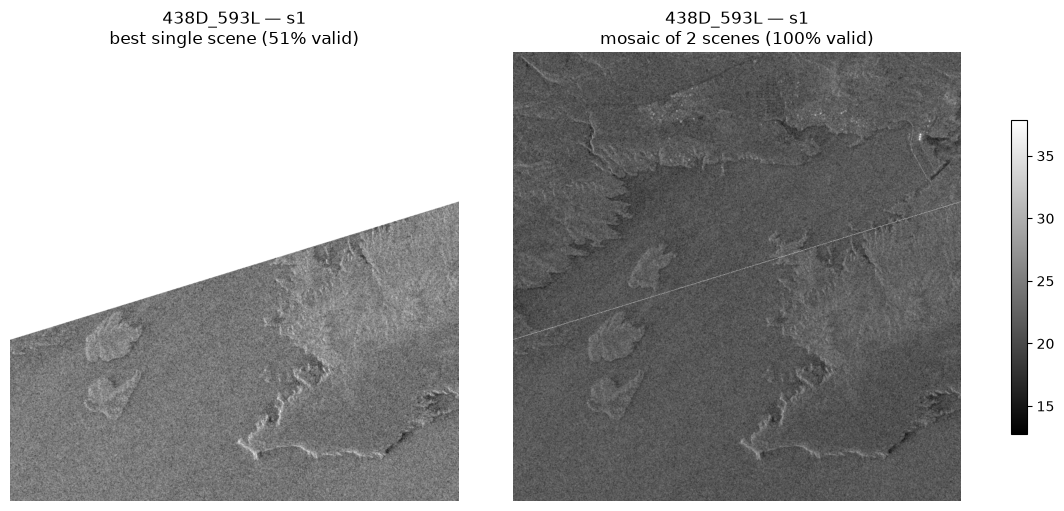

In [9]:
import matplotlib.pyplot as plt

def valid_frac(arr: np.ndarray) -> float:
    return float(np.isfinite(arr).mean())

def single_scene(uri: str, bounds) -> np.ndarray:
    """One scene windowed to the cell GeoBox -> (bands, y, x)."""
    with rasterio.open(uri) as src:
        arr, _ = merge([src], bounds=bounds, masked=True)
        return np.asarray(arr.filled(np.nan), dtype="float32")

# Pick the (cell, slot) where mosaicking gained the most coverage.
gains = {}
for cell_id in common_cells:
    cell = samples[samples.grid_cell == cell_id]
    bounds = cell_bounds[cell_id]
    for slot in SLOTS:
        rows = cell[cell.slot == slot]
        uris = list(dict.fromkeys(rows.uri))
        if len(uris) < 2:
            continue
        best_single = max(valid_frac(single_scene(u, bounds)) for u in uris)
        gains[(cell_id, slot)] = valid_frac(mosaic(rows, bounds)) - best_single

cell_id, slot = max(gains, key=gains.get)
bounds = cell_bounds[cell_id]
rows = samples[(samples.grid_cell == cell_id) & (samples.slot == slot)]
uris = list(dict.fromkeys(rows.uri))
best_uri = max(uris, key=lambda u: valid_frac(single_scene(u, bounds)))
before = single_scene(best_uri, bounds)[0]
after = mosaic(rows, bounds)[0]

cmap = "RdYlGn" if slot.startswith("ndvi") else "gray"
if slot == "s1":  # dB for display, as in the final plot
    before = 10 * np.log10(np.clip(before, 1e-6, None))
    after = 10 * np.log10(np.clip(after, 1e-6, None))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, arr, title in zip(axes, [before, after], ["best single scene", f"mosaic of {len(uris)} scenes"]):
    im = ax.imshow(arr, cmap=cmap, **({"vmin": -1, "vmax": 1} if cmap == "RdYlGn" else {}))
    ax.set_title(f"{cell_id} — {slot}\n{title} ({valid_frac(arr):.0%} valid)")
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.7)
plt.show()

## Step 4 — One multi-sensor tensor

The per-cell mosaics stack into the final `xarray` tensor: each sample is a grid cell with 4 channels — `ndvi_t1`, `ndvi_t2` (1 band each) and `vv`, `vh` (from the 2-band Sentinel-1 raster). Every array here is cell-sized, windowed from the shared rasters — no full-AOI rasters in memory.

In [10]:
import xarray as xr

tensor = xr.DataArray(
    data,
    dims=("sample", "channel", "y", "x"),
    coords={"sample": common_cells, "channel": CHANNELS},
)
tensor

<xarray.DataArray (sample: 10, channel: 4, y: 1100, x: 1100)> Size: 194MB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [ 1.47319108e-01,  1.41382873e-01,  1.42419606e-01, ...,
                      nan,             nan,             nan],
         [ 1.41219392e-01,  1.37984499e-01,  1.48205921e-01, ...,
                      nan,             nan,             nan],
         [ 1.51771545e-01,  1.50105715e-01,  1.37130797e-01, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
...
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[ 4.40000000e+01,  4.50000000e+01,  6.40000000e+01, ...,
           4.00000000e+01,  3.10000000e+01,  3.60000000e+01],
         [ 3.70000000e+01,  4.00000000e+01,  4.60000000e+01, ...,
           3.60000000e+01,  3.50000000e+01,  4.30000000e+01],
         [ 4.10000000e+01,  4.50000000e+01,  5.30000000e+01, ...,
           2.80000000e+01,  3.10000000e+01,  3.10000000e+01],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]]]],
      shape=(10, 4, 1100, 1100), dtype=float32)
Coordinates:
  * sample   (sample) <U9 360B '437D_592L' '437D_593L' ... '439D_593L'
  * channel  (channel) <U7 112B 'ndvi_t1' 'ndvi_t2' 'vv' 'vh'
Dimensions without coordinates: y, x

## Step 5 — The deliverable: one Major TOM index for all constellations

The merged index is just the **concatenation of the three artifact catalogs** — no grouping, no compression. Like the [Major-TOM Core datasets](https://huggingface.co/datasets/Major-TOM/Core-S2L2A), it keeps **one row per observation**: a `grid_cell` appears once per scene and time slot, and rows are identified by their `start_time`/`end_time`. That keeps every observation addressable — you decide later whether to mosaic, stack a time series, or pick the latest.

Because all three catalogs share the same schema (`grid_cell`, `start_time`, `uri`, `cell_geometry`, …), merging is a plain `concat`. This is the table you hand to the rest of your stack: filter by cell or time, window-read the referenced rasters, and every row is guaranteed to reference the same pixels on the ground across sensors.

In [11]:
# The merged Major TOM index: one row per (grid cell, scene, slot).
# Repeated grid_cell values are intentional — identified by start/end time.
merged = (
    pd.concat([cat_t1, cat_t2, cat_s1], ignore_index=True)
    .sort_values(["grid_cell", "start_time"])
    .reset_index(drop=True)
)

index_path = "/tmp/aereo_ml/majortom_index.parquet"
merged.to_parquet(index_path)
print(f"Major TOM index written to {index_path}")
print(f"{len(merged)} rows, {merged.grid_cell.nunique()} unique cells, "
      f"{merged.uri.nunique()} unique rasters, "
      f"{merged.collection.nunique()} collections: {sorted(merged.collection.unique())}")

# Read it back: the merged, multi-constellation catalog.
gpd.read_parquet(index_path)[["grid_cell", "slot", "collection", "start_time", "uri"]].head(8)

Major TOM index written to /tmp/aereo_ml/majortom_index.parquet
90 rows, 10 unique cells, 12 unique rasters, 2 collections: ['sentinel-1-grd', 'sentinel-2-l2a']


,grid_cell,slot,collection,start_time,uri
0,437D_592L,ndvi_t1,sentinel-2-l2a,2024-01-02 14:33:47.691000,/tmp/aereo_ml/ndvi_t1/job-ndvi_t1/date-2024010...
1,437D_592L,ndvi_t2,sentinel-2-l2a,2024-01-10 14:43:37.378000,/tmp/aereo_ml/ndvi_t2/job-ndvi_t2/date-2024011...
2,437D_592L,ndvi_t2,sentinel-2-l2a,2024-01-12 14:33:45.063000,/tmp/aereo_ml/ndvi_t2/job-ndvi_t2/date-2024011...
3,437D_592L,ndvi_t2,sentinel-2-l2a,2024-01-17 14:33:38.600000,/tmp/aereo_ml/ndvi_t2/job-ndvi_t2/date-2024011...
4,437D_592L,ndvi_t2,sentinel-2-l2a,2024-01-20 14:43:34.277000,/tmp/aereo_ml/ndvi_t2/job-ndvi_t2/date-2024012...
5,437D_592L,s1,sentinel-1-grd,2024-03-23 23:26:36.019841,/tmp/aereo_ml/s1/job-s1/date-20240323/collecti...
6,437D_592L,s1,sentinel-1-grd,2024-03-23 23:27:01.019808,/tmp/aereo_ml/s1/job-s1/date-20240323/collecti...
7,437D_593L,ndvi_t1,sentinel-2-l2a,2024-01-02 14:33:47.691000,/tmp/aereo_ml/ndvi_t1/job-ndvi_t1/date-2024010...


## Sanity check — same cell, three views

Mosaicked NDVI at t1 and t2 next to the mosaicked SAR `vv` backscatter (shown in dB for contrast), all windowed to the **same GeoBox per cell**. Rows are samples, columns are channels — the layout of a training batch. The reservoir is unambiguous in SAR (dark = smooth open water) even where optical is cloudy or ambiguous: the classic SAR+optical fusion motivation, delivered as aligned tensors.

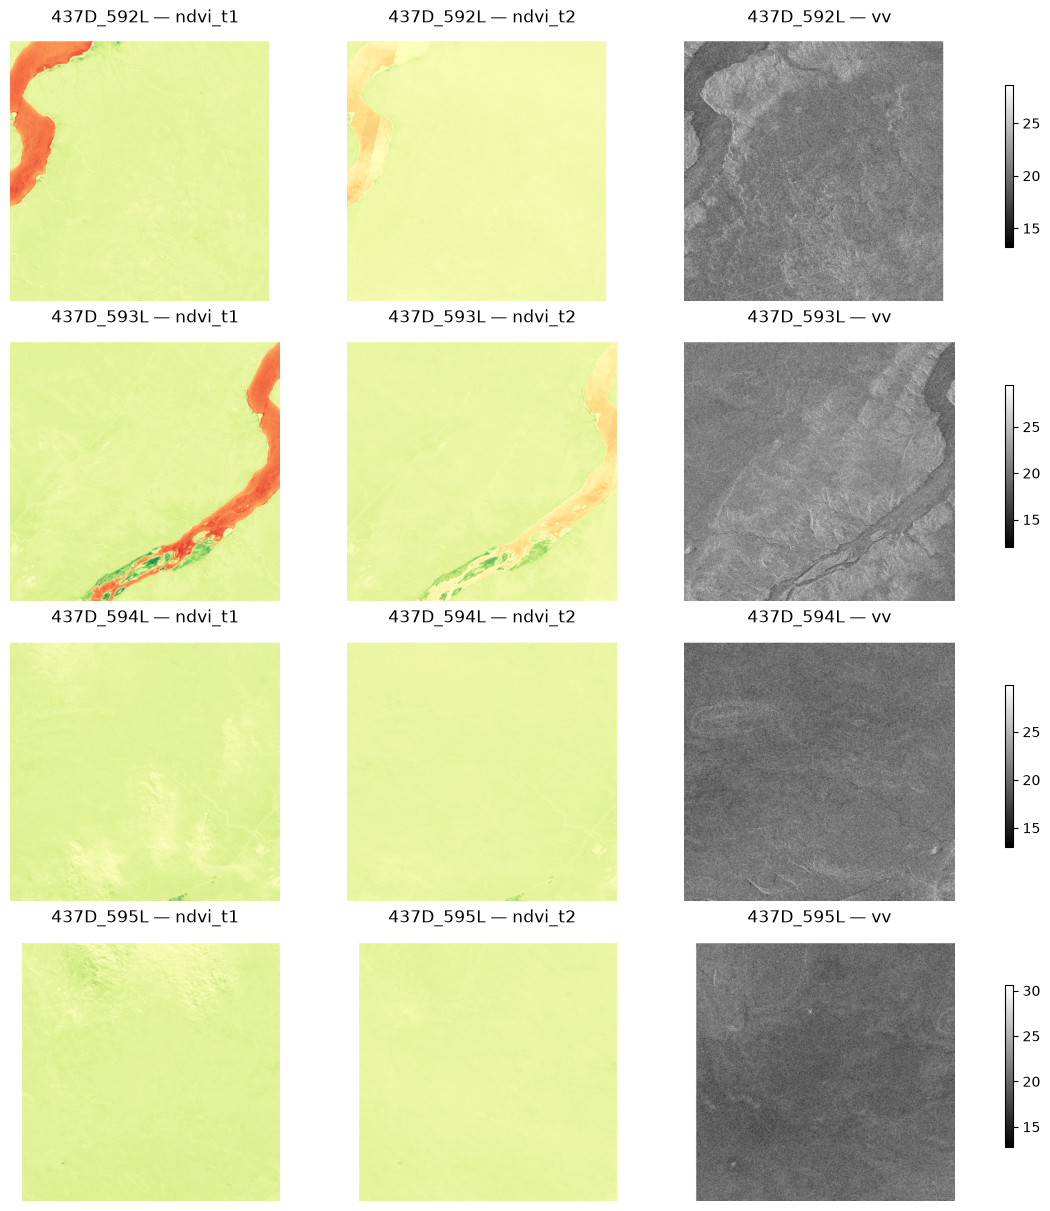

In [12]:
n_show = min(4, len(common_cells))
fig, axes = plt.subplots(n_show, 3, figsize=(11, 3 * n_show), constrained_layout=True)
for i in range(n_show):
    for j, ch in enumerate(["ndvi_t1", "ndvi_t2", "vv"]):
        ax = axes[i, j]
        band = tensor.sel(sample=common_cells[i], channel=ch).values
        if ch == "vv":
            band = 10 * np.log10(np.clip(band, 1e-6, None))  # dB for display
            im = ax.imshow(band, cmap="gray")
        else:
            im = ax.imshow(band, cmap="RdYlGn", vmin=-1, vmax=1)
        ax.set_title(f"{common_cells[i]} — {ch}")
        ax.axis("off")
    fig.colorbar(im, ax=axes[i, :].tolist(), shrink=0.6)
plt.show()

## Loading a single cell from the index

Filter the index to one `grid_cell` and you get every observation of that cell across constellations and dates. Window-read each referenced raster with the cell's GeoBox, mosaic per slot, done — the full-AOI GeoTIFFs are never loaded entirely.

7 index rows for cell 437D_592L:
   slot     collection                 start_time
ndvi_t1 sentinel-2-l2a 2024-01-02 14:33:47.691000
ndvi_t2 sentinel-2-l2a 2024-01-10 14:43:37.378000
ndvi_t2 sentinel-2-l2a 2024-01-12 14:33:45.063000
ndvi_t2 sentinel-2-l2a 2024-01-17 14:33:38.600000
ndvi_t2 sentinel-2-l2a 2024-01-20 14:43:34.277000
     s1 sentinel-1-grd 2024-03-23 23:26:36.019841
     s1 sentinel-1-grd 2024-03-23 23:27:01.019808

 {'ndvi_t1': (1, 1100, 1100), 'ndvi_t2': (1, 1100, 1100), 's1': (2, 1100, 1100)}


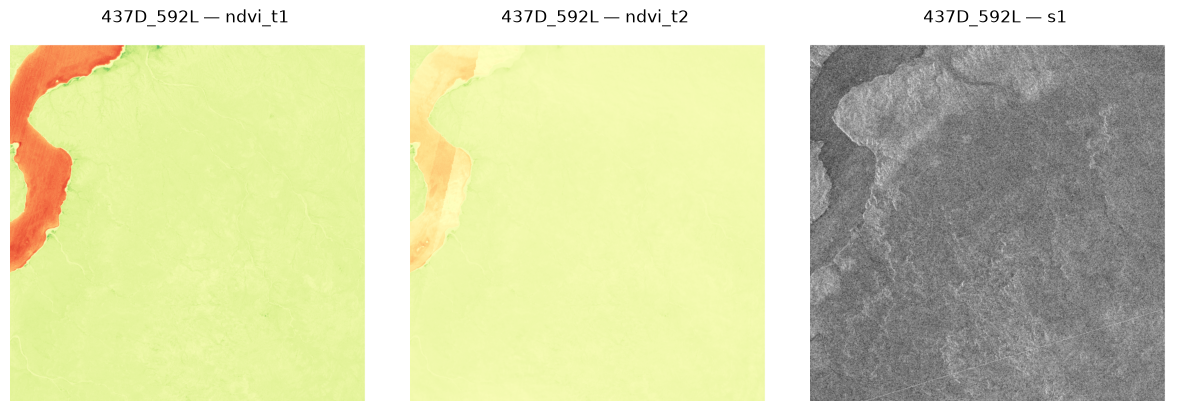

In [13]:
cell_id = "437D_592L"  # pick any cell from the index
rows = merged[merged.grid_cell == cell_id]
bounds = cell_bounds[cell_id]

print(f"{len(rows)} index rows for cell {cell_id}:")
print(rows[["slot", "collection", "start_time"]].to_string(index=False))

def load_cell(rows: pd.DataFrame, bounds) -> dict[str, np.ndarray]:
    """Rebuild one cell's mosaicked channels from its index rows (windowed reads)."""
    out = {}
    for slot in SLOTS:
        aligned = []
        for uri in dict.fromkeys(rows[rows.slot == slot].uri):
            with rasterio.open(uri) as src:
                arr, _ = merge([src], bounds=bounds, masked=True)
                aligned.append(np.asarray(arr.filled(np.nan), dtype="float32"))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            out[slot] = np.nanmean(np.stack(aligned), axis=0)
    return out

channels = load_cell(rows, bounds)
print("\n", {k: v.shape for k, v in channels.items()})  # cell-sized, not AOI-sized

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
views = [("ndvi_t1", "RdYlGn", (-1, 1)), ("ndvi_t2", "RdYlGn", (-1, 1)), ("s1", "gray", None)]
for ax, (slot, cmap, vminmax) in zip(axes, views):
    arr = channels[slot][0]
    if slot == "s1":
        arr = 10 * np.log10(np.clip(arr, 1e-6, None))  # vv in dB
    kwargs = {"vmin": vminmax[0], "vmax": vminmax[1]} if vminmax else {}
    ax.imshow(arr, cmap=cmap, **kwargs)
    ax.set_title(f"{cell_id} — {slot}")
    ax.axis("off")
plt.show()